<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº5
#### Nicolás Galván

# Introducción

En este trabajo se realizó el análisis espectral de distintas señales biomédicas y de audio mediante la estimación de su Densidad Espectral de Potencia (PSD, *Power Spectral Density*). Las señales analizadas corresponden a un electrocardiograma (ECG), una señal de pletismografía (PPG) y distintos registros de audio, incluyendo voz y silbidos.

La PSD permite estudiar cómo se distribuye la potencia de una señal en función de la frecuencia, siendo una herramienta fundamental para identificar componentes dominantes, contenido armónico y características espectrales relevantes de cada tipo de señal. Para la estimación espectral se utilizó el método de Welch, el cual mejora la varianza del periodograma clásico mediante el promedio de estimaciones obtenidas sobre segmentos solapados de la señal.

El procesamiento se realizó utilizando Python y las librerías `NumPy`, `SciPy` y `Matplotlib`. Para cada señal se calculó su PSD normalizada y expresada en decibeles, permitiendo comparar de manera más clara el contenido frecuencial de los distintos registros.

Además, se realizó una estimación del ancho de banda de cada señal utilizando el criterio de potencia acumulada del 95%, considerando como frecuencias límite aquellas que contienen entre el 2.5% y el 97.5% de la potencia total. Finalmente, los resultados obtenidos se presentan en forma gráfica y tabulada para facilitar la comparación entre señales biomédicas y de audio.

# Ejercicio Nº1

## ECG

Llamo a las librerías a utilizar.

In [290]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio

Defino mi frecuencia de muestreo del ECG.

In [291]:
fs_ecg = 1000  # Hz

Leo el archivo .mat para obtener las muestras de la señal ECG_TP4.

In [292]:
mat = sio.loadmat('ECG_TP4.mat')

Extraigo la variable ecg_lead.

In [293]:
ecg_one_lead = mat['ecg_lead'].flatten()

Cálculo la Densidad Espectral de Potencia (PSD) usando Welch.

In [294]:
fs_ecg_welch, ecg_psd = sig.welch(ecg_one_lead, fs_ecg, detrend="constant", nperseg=len(ecg_one_lead)//10)

Normalizo y paso a dB.

In [295]:
ecg_psd_norm = ecg_psd / np.max(ecg_psd)
ecg_psd_db   = 10 * np.log10(ecg_psd_norm)

Gráfico la PSD del ECG.

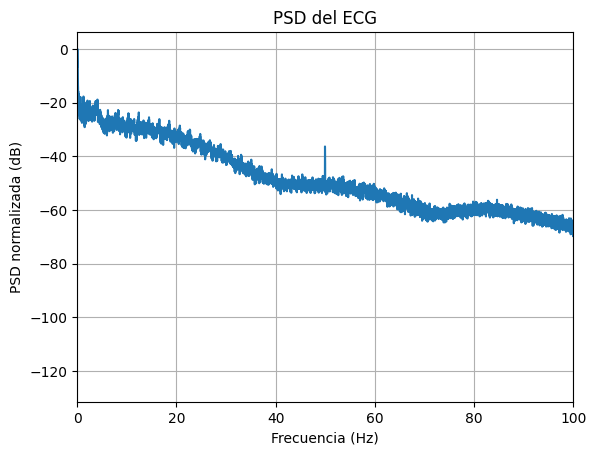

In [296]:
plt.figure()
plt.plot(fs_ecg_welch, ecg_psd_db)
plt.xlim(0, 100) # rango fisiológico ECG
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD normalizada (dB)")
plt.title("PSD del ECG")
plt.grid(True)
plt.show()

## PPG

Defino mi frecuencia de muestreo de PPG.

In [297]:
fs_ppg = 400  # Hz

Leo el archivo .csv para obtener las muestras de la señal PPG.

In [298]:
ppg = np.loadtxt('PPG.csv', delimiter=',')

Cálculo la Densidad Espectral de Potencia (PSD) usando Welch.

In [299]:
fs_ppg_welch, ppg_psd = sig.welch(ppg, fs_ppg, detrend="constant", nperseg=len(ppg)//10)

Normalizo y paso a dB.

In [300]:
ppg_psd_norm = ppg_psd / np.max(ppg_psd)
ppg_psd_db   = 10 * np.log10(ppg_psd_norm)

Gráfico la PSD de la PPG.

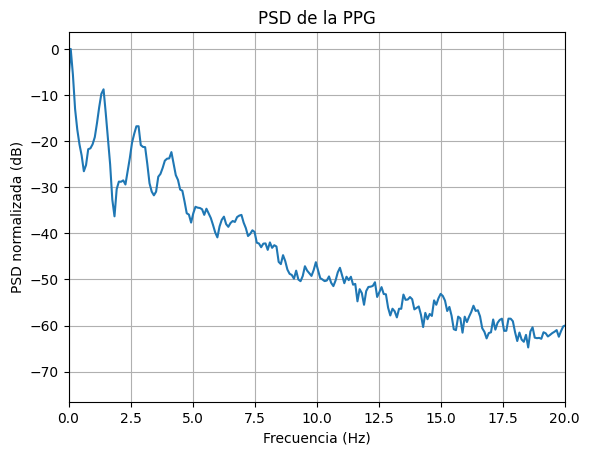

In [301]:
plt.figure()
plt.plot(fs_ppg_welch, ppg_psd_db)
plt.xlim(0, 20)   # rango fisiológico PPG
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD normalizada (dB)")
plt.title("PSD de la PPG")
plt.grid(True)
plt.show()

## Audio - La Cucaracha

Leo archivo para obtener la frecuencia de muestreo y las muestras del audio.

In [302]:
fs_cu,   wav_cu   = sio.wavfile.read('la cucaracha.wav')

Convierto a float para evitar overflow en Welch.

In [303]:
wav_cu = wav_cu.astype(np.float64)

Creo mi vector temporal.

In [304]:
t_cu = np.arange(len(wav_cu)) / fs_cu

Cálculo la Densidad Espectral de Potencia (PSD) usando Welch.

In [305]:
fs_Cu, Wav_cu = sig.welch(wav_cu, fs_cu, detrend="constant", nperseg=len(wav_cu)//10)

Normalizo y paso a dB.

In [306]:
Wav_cu_norm = Wav_cu / np.max(Wav_cu)
Wav_cu_db   = 10 * np.log10(Wav_cu_norm)

Gráfico la PSD de la Cucaracha.

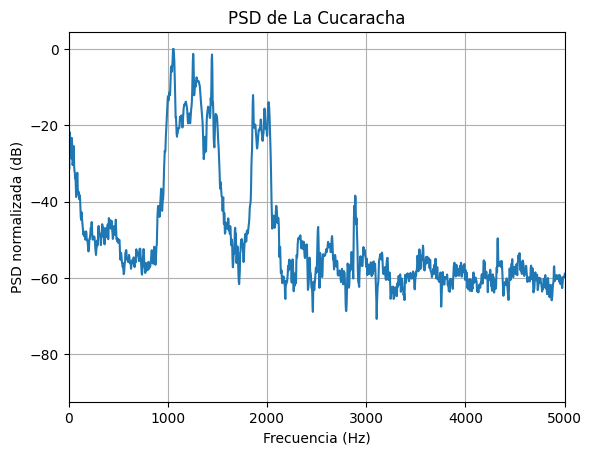

In [307]:
plt.figure()
plt.plot(fs_Cu, Wav_cu_db)
plt.xlim(0, 5000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD normalizada (dB)")
plt.title("PSD de La Cucaracha")
plt.grid(True)
plt.show()

## Audio - Prueba psd

Leo archivo para obtener la frecuencia de muestreo y las muestras del audio.

In [308]:
fs_psd,  wav_psd  = sio.wavfile.read('prueba psd.wav')

Convierto a float para evitar overflow en Welch.

In [309]:
wav_psd = wav_psd.astype(np.float64)

Creo mi vector temporal.

In [310]:
t_cu = np.arange(len(wav_psd)) / fs_psd

Cálculo la Densidad Espectral de Potencia (PSD) usando Welch.

In [311]:
fs_Psd, Wav_psd = sig.welch(wav_psd, fs_psd, detrend="constant", nperseg=len(wav_psd)//10)

Normalizo y paso a dB.

In [312]:
Wav_psd_norm = Wav_psd / np.max(Wav_psd)
Wav_psd_db   = 10 * np.log10(Wav_psd_norm)

Gráfico la PSD de Prueba PSD.

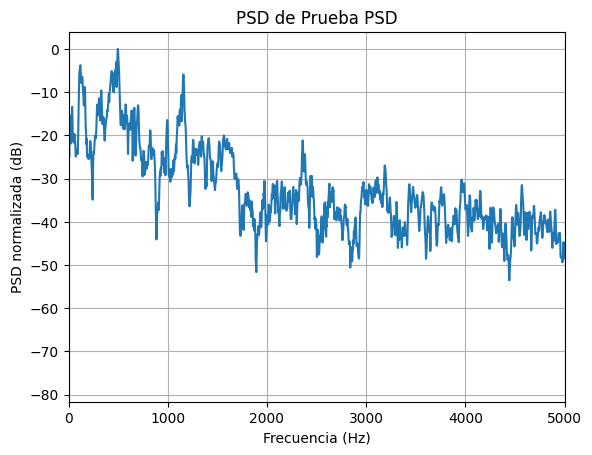

In [313]:
plt.figure()
plt.plot(fs_Psd, Wav_psd_db)
plt.xlim(0, 5000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD normalizada (dB)")
plt.title("PSD de Prueba PSD")
plt.grid(True)
plt.show()

## Audio - Silbido

Leo archivo para obtener la frecuencia de muestreo y las muestras del audio.

In [314]:
fs_silb, wav_silb = sio.wavfile.read('silbido.wav')

Convierto a float para evitar overflow en Welch.

In [ ]:
wav_silb = wav_silb.astype(np.float64)

Creo mi vector temporal.

In [ ]:
t_cu = np.arange(len(wav_silb)) / fs_silb

Cálculo la Densidad Espectral de Potencia (PSD) usando Welch.

In [ ]:
fs_Silb, Wav_Silb = sig.welch(wav_silb, fs_silb, detrend="constant", nperseg=len(wav_silb)//10)

Normalizo y paso a dB.

In [ ]:
Wav_Silb_norm = Wav_Silb / np.max(Wav_Silb)
Wav_Silb_db   = 10 * np.log10(Wav_Silb_norm)

Gráfico la PSD de Silbido.

In [ ]:
plt.figure()
plt.plot(fs_Silb, Wav_Silb_db)
plt.xlim(0, 7000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD normalizada (dB)")
plt.title("PSD de Silbido")
plt.grid(True)
plt.show()

# Ejercicio Nº2

In [ ]:
def calcular_bw(freqs, psd, criterio_inf=0.025, criterio_sup=0.975):
    potencia_total = np.sum(psd * np.diff(freqs, prepend=freqs[0]))
    potencia_acum  = np.cumsum(psd * np.diff(freqs, prepend=freqs[0]))
    potencia_norm  = potencia_acum / potencia_total

    idx_inf = np.clip(np.searchsorted(potencia_norm, criterio_inf), 0, len(freqs) - 1)
    idx_sup = np.clip(np.searchsorted(potencia_norm, criterio_sup), 0, len(freqs) - 1)

    f_inf = freqs[idx_inf]
    f_sup = freqs[idx_sup]
    bw    = f_sup - f_inf

    return f_inf, f_sup, bw

# ── Calcular BW para cada señal ───────────────────────────────────────────────
bw_ecg  = calcular_bw(fs_ecg_welch, ecg_psd)
bw_ppg  = calcular_bw(fs_ppg_welch, ppg_psd)
bw_cu   = calcular_bw(fs_Cu,        Wav_cu)
bw_psd  = calcular_bw(fs_Psd,       Wav_psd)
bw_silb = calcular_bw(fs_Silb,      Wav_Silb)

# ── Tabla de resultados ───────────────────────────────────────────────────────
señales = ["ECG", "PPG", "La Cucaracha", "Prueba PSD", "Silbido"]
resultados = [bw_ecg, bw_ppg, bw_cu, bw_psd, bw_silb]

print("=" * 60)
print(f"{'Señal':<15} {'F inf (Hz)':>12} {'F sup (Hz)':>12} {'BW (Hz)':>12}")
print("=" * 60)
for nombre, (f_inf, f_sup, bw) in zip(señales, resultados):
    print(f"{nombre:<15} {f_inf:>12.2f} {f_sup:>12.2f} {bw:>12.2f}")
print("=" * 60)

**Criterio utilizado:** 95% de potencia central (2.5% - 97.5%).

| Señal          | F inf (Hz) | F sup (Hz) | BW (Hz) |
|----------------|------------|------------|----------|
| ECG            | 0.01       | 21.49      | 21.49    |
| PPG            | 0.09       | 3.09       | 3.00     |
| La Cucaracha   | 1013.33    | 1940.00    | 926.67   |
| Prueba PSD     | 106.67     | 1570.00    | 1463.33  |
| Silbido        | 3003.33    | 6430.00    | 3426.67  |

---

# Análisis de Resultados


A partir de la estimación de la PSD mediante el método de Welch y utilizando el criterio de potencia acumulada del 95%, se obtuvieron diferentes anchos de banda para cada tipo de señal analizada.

Las señales biomédicas presentan anchos de banda considerablemente menores en comparación con las señales de audio. En particular, la señal de PPG posee el menor ancho de banda (\~3 Hz), lo cual es esperable debido a que su contenido frecuencial está asociado principalmente al ritmo cardíaco y a variaciones lentas del flujo sanguíneo. Esto también puede observarse en la PSD, donde la mayor parte de la energía se concentra en frecuencias muy bajas.

Por otro lado, el ECG presenta un ancho de banda mayor (\~21 Hz), ya que además de la frecuencia cardíaca incluye componentes asociadas a las ondas características del electrocardiograma (ondas P, QRS y T), las cuales aportan contenido espectral en frecuencias superiores. En la PSD se observa que la energía se distribuye sobre un rango más amplio respecto de la PPG.

En las señales de audio se obtuvieron anchos de banda significativamente más elevados. La señal correspondiente a *La Cucaracha* presenta un ancho de banda cercano a 927 Hz, concentrando la energía en un rango relativamente acotado de frecuencias, asociado principalmente a las notas musicales predominantes de la melodía.

La señal denominada *Prueba PSD* posee un ancho de banda aún mayor (\~1463 Hz), indicando una distribución espectral más amplia, compatible con una señal de voz hablada, donde intervienen múltiples componentes armónicas y formantes.

Finalmente, el *Silbido* presenta el mayor ancho de banda (\~3427 Hz). En la PSD puede observarse una importante concentración de energía en frecuencias altas, característica típica de señales de silbido, las cuales contienen componentes dominantes en el rango de varios kilohertz.

En general, los resultados obtenidos son consistentes con lo esperado para cada tipo de señal y coinciden con las características observadas visualmente en las PSD calculadas.

--- 
 

En los gráficos de densidad espectral de potencia (PSD) puede observarse que cada señal presenta una distribución espectral acorde a su naturaleza física.

La señal de **ECG** concentra la mayor parte de su energía en bajas frecuencias, principalmente por debajo de los 25 Hz. Esto coincide con el comportamiento esperado de un electrocardiograma, donde las componentes asociadas al complejo QRS y al ritmo cardíaco predominan en ese rango frecuencial.

La señal de **PPG** presenta un espectro aún más angosto, con energía concentrada en frecuencias muy bajas, cercanas a la frecuencia cardíaca. La PSD muestra una rápida disminución de potencia fuera de ese rango, lo cual es coherente con una señal fisiológica de variación lenta.

En las señales de **audio** se observa un contenido espectral mucho más amplio. En *La Cucaracha* aparecen componentes dominantes relativamente concentradas en determinadas bandas de frecuencia, asociadas a las notas musicales de la melodía.

La señal de *Prueba PSD* exhibe un espectro más distribuido, típico de señales de voz hablada, donde intervienen múltiples armónicos y formantes que ocupan un rango frecuencial amplio.

Por último, el gráfico correspondiente al *Silbido* muestra una fuerte concentración de energía en frecuencias altas, característica esperable de este tipo de señales. Además, se aprecia un ancho de banda considerablemente mayor respecto de las demás señales analizadas.

En general, las PSD obtenidas permiten diferenciar claramente las características espectrales de cada señal y muestran resultados consistentes con el comportamiento esperado teóricamente.

---

# Autoevaluación del aprendizaje

Durante el desarrollo de este trabajo práctico se logró aplicar de manera práctica los conceptos teóricos relacionados con el análisis espectral de señales y la estimación de densidad espectral de potencia (PSD). Se trabajó con señales biomédicas y de audio reales, permitiendo observar diferencias claras en el contenido frecuencial de cada una.

Uno de los principales aprendizajes fue la utilización del método de Welch para la estimación de la PSD, comprendiendo sus ventajas respecto del periodograma clásico, especialmente en términos de reducción de la varianza de la estimación. También se reforzó el manejo de herramientas de procesamiento digital de señales en Python utilizando bibliotecas como `NumPy`, `SciPy` y `Matplotlib`.

Además, se comprendió la relación entre las características físicas de una señal y su representación en frecuencia. Por ejemplo, las señales biomédicas presentaron energía concentrada en bajas frecuencias, mientras que las señales de audio ocuparon rangos espectrales mucho más amplios.

La estimación del ancho de banda mediante potencia acumulada permitió complementar el análisis visual de las PSD y obtener una medida cuantitativa para comparar las distintas señales estudiadas.

Como aspecto a mejorar, podría profundizarse el análisis utilizando otros métodos de estimación espectral, como Blackman-Tukey o periodogramas ventaneados, con el objetivo de comparar resolución espectral, varianza y comportamiento frente a distintos tipos de señales.

En general, el trabajo permitió consolidar conceptos de análisis espectral, interpretación de PSD y procesamiento digital de señales aplicados a casos reales.